# Private submission response analysis

QA and **post-upload leaderboard review** for **`results/submission_32k.csv`** against **`data/private.jsonl`**.

- **§1–§10:** completeness, truncation, format readiness (what the grader extracts).
- **§11:** leaderboard **0.48** vs **pub-003** public 32k (~65.8%) — gap decomposition via format buckets calibrated on `data/full_public_32k.jsonl`.
- **§12:** export flags / summary JSON.

Set **`LEADERBOARD_SCORE`** in §1 after each upload. Leaderboard reports on ~30% of private until finals.

## 1. Configuration

In [1]:
import csv
import importlib.util
import json
import os
import re
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt

    plt.rcParams["figure.dpi"] = 110
    HAS_MPL = True
except ImportError:
    HAS_MPL = False


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "data").is_dir() and (here / "judger.py").is_file():
        return here
    if here.name == "notebooks" and (here.parent / "data").is_dir():
        return here.parent
    return here


REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

RUN_ID = "priv-001"
MAX_TOKENS = 32_768
NEAR_CAP_CHARS = 79_000
Q4_LONG_CHARS = 435

# Leaderboard feedback (interim ~30% of private until finals)
LEADERBOARD_SCORE = 0.48  # unified accuracy reported by grader
PUB_32K_RUN = "pub-003"
PUBLIC_32K_PATH = REPO_ROOT / "data" / "full_public_32k.jsonl"
PUBLIC_PATH = REPO_ROOT / "data" / "public.jsonl"

PRIVATE_PATH = REPO_ROOT / "data" / "private.jsonl"
RESPONSES_PATH = REPO_ROOT / "results" / "submission_32k.csv"
SUBMISSION_CSV = REPO_ROOT / "results" / "submission_32k.csv"
COMPARE_PATH = None  # optional second responses JSONL for paired diff

FLAGS_PATH = REPO_ROOT / "results" / "submission_flags.jsonl"
SUMMARY_PATH = REPO_ROOT / "results" / "submission_analysis_summary.json"

THINK_ENDS = ("</" + "think>", "</" + "redacted_thinking>")
THINK_END_LABEL = " or ".join(THINK_ENDS)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"PRIVATE_PATH: {PRIVATE_PATH}")
print(f"RESPONSES_PATH: {RESPONSES_PATH}")

REPO_ROOT: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition
PRIVATE_PATH: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/data/private.jsonl
RESPONSES_PATH: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/results/submission_32k.csv


## 2. Load & merge

In [2]:
def load_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


def load_responses(path: Path) -> dict[int, str]:
    if not path.is_file():
        raise FileNotFoundError(path)
    if path.suffix.lower() == ".csv":
        with path.open(newline="", encoding="utf-8") as f:
            rows = list(csv.DictReader(f))
        return {int(r["id"]): r["response"] for r in rows}
    rows = load_jsonl(path)
    return {int(r["id"]): r["response"] for r in rows}


_spec = importlib.util.spec_from_file_location(
    "sft_prompt", REPO_ROOT / "scripts" / "sft_prompt.py"
)
_sft_prompt = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_sft_prompt)
n_ans_placeholders = _sft_prompt.n_ans_placeholders
extract_all_boxed = _sft_prompt.extract_all_boxed

from judger import Judger
from scripts.topic_classify import classify_topic

judger = Judger(strict_extract=False)

private = load_jsonl(PRIVATE_PATH)
response_by_id = load_responses(RESPONSES_PATH)

compare_by_id = None
if COMPARE_PATH:
    compare_by_id = load_responses(Path(COMPARE_PATH))
    print(f"Compare: {COMPARE_PATH} ({len(compare_by_id)} rows)")


def _last_think_end(resp: str) -> tuple[int, str] | None:
    best_pos, best_tag = -1, None
    for tag in THINK_ENDS:
        i = resp.rfind(tag)
        if i > best_pos:
            best_pos, best_tag = i, tag
    return (best_pos, best_tag) if best_tag is not None and best_pos >= 0 else None


def has_think_finished(resp: str) -> bool:
    return _last_think_end(resp) is not None


def response_tail(resp: str) -> str:
    hit = _last_think_end(resp)
    return resp[hit[0] + len(hit[1]) :] if hit else resp


def count_raw_boxed(text: str) -> int:
    n, start = 0, 0
    while True:
        idx = text.find("\\boxed{", start)
        if idx < 0:
            break
        n += 1
        i = idx + len("\\boxed{")
        depth = 1
        while i < len(text) and depth > 0:
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
            i += 1
        start = i
    return n


def extract_letter(text: str) -> str:
    m = re.search(r"\\boxed\{([A-Za-z])\}", text)
    if m:
        return m.group(1).upper()
    matches = re.findall(r"\b([A-Z])\b", text.upper())
    return matches[-1] if matches else ""


def mcq_has_boxed_letter(response: str, n_options: int) -> bool:
    if n_options <= 0:
        return False
    last = chr(64 + n_options)
    return bool(re.search(rf"\\boxed\{{[A-{last}]\}}", response, re.IGNORECASE))


rows = []
for item in private:
    pid = item["id"]
    q = item.get("question", "")
    opts = item.get("options") or []
    is_mcq = bool(opts)
    resp = response_by_id.get(pid, "")
    tail = response_tail(resp)
    n_blanks = 1 if is_mcq else n_ans_placeholders(q)
    boxed = extract_all_boxed(tail) if not is_mcq else []
    n_extracted = len(boxed)
    think_finished = has_think_finished(resp)
    rows.append(
        {
            "id": pid,
            "is_mcq": is_mcq,
            "n_options": len(opts),
            "n_blanks": n_blanks,
            "question": q,
            "q_len": len(q),
            "response": resp,
            "resp_len": len(resp),
            "think_finished": think_finished,
            "near_cap_chars": len(resp) >= NEAR_CAP_CHARS,
            "topic": classify_topic(q),
            "boxed": boxed,
            "n_extracted": n_extracted,
            "n_raw_boxed": count_raw_boxed(tail),
            "count_ok": (not is_mcq) and (n_extracted == n_blanks),
            "no_boxed": (not is_mcq) and (n_extracted == 0),
            "count_short": (not is_mcq) and (0 < n_extracted < n_blanks),
            "count_long": (not is_mcq) and (n_extracted > n_blanks),
            "non_contiguous": (not is_mcq) and (count_raw_boxed(tail) > n_extracted),
            "mcq_boxed": mcq_has_boxed_letter(resp, len(opts)) if is_mcq else False,
            "mcq_letter": extract_letter(resp) if is_mcq else "",
            "extracted_preview": (
                extract_letter(resp) if is_mcq else ", ".join(boxed[:6])
            ),
        }
    )
    rows[-1]["format_ok"] = rows[-1]["mcq_boxed"] if is_mcq else rows[-1]["count_ok"]

df = pd.DataFrame(rows)
mcq = df[df.is_mcq]
ff = df[~df.is_mcq]

print(f"Private questions: {len(private)}")
print(f"Responses loaded:  {len(response_by_id)}")
print(f"Merged rows:       {len(df)}  |  MCQ: {len(mcq)}  |  Free-form: {len(ff)}")

Private questions: 943
Responses loaded:  943
Merged rows:       943  |  MCQ: 300  |  Free-form: 643


## 3. Integrity gates (block upload if any FAIL)

In [3]:
expected_ids = {item["id"] for item in private}
response_ids = set(response_by_id.keys())

missing_ids = sorted(expected_ids - response_ids)
extra_ids = sorted(response_ids - expected_ids)
dup_ids = []
if RESPONSES_PATH.suffix.lower() == ".jsonl":
    seen: Counter = Counter()
    for line in RESPONSES_PATH.open(encoding="utf-8"):
        if line.strip():
            seen[int(json.loads(line)["id"])] += 1
    dup_ids = sorted(i for i, c in seen.items() if c > 1)

empty_ids = sorted(r["id"] for r in rows if not (r["response"] or "").strip())

csv_ok = None
if SUBMISSION_CSV.is_file() and RESPONSES_PATH.suffix.lower() == ".jsonl":
    csv_map = load_responses(SUBMISSION_CSV)
    csv_ok = (
        set(csv_map.keys()) == expected_ids
        and all(csv_map[i] == response_by_id[i] for i in expected_ids)
    )

gates = [
    ("row_count", len(response_by_id) == len(private), f"{len(response_by_id)}/{len(private)}"),
    ("no_missing_ids", not missing_ids, missing_ids[:10]),
    ("no_extra_ids", not extra_ids, extra_ids[:10]),
    ("no_duplicates", not dup_ids, dup_ids[:10]),
    ("no_empty_responses", not empty_ids, empty_ids[:10]),
]
if csv_ok is not None:
    gates.append(("csv_matches_jsonl", csv_ok, SUBMISSION_CSV.name))

all_pass = True
for name, ok, detail in gates:
    status = "PASS" if ok else "FAIL"
    if not ok:
        all_pass = False
    print(f"  {name:<22} {status:<5}  {detail}")

print()
print("OVERALL:", "PASS — safe to analyze/upload" if all_pass else "FAIL — fix before upload")

  row_count              PASS   943/943
  no_missing_ids         PASS   []
  no_extra_ids           PASS   []
  no_duplicates          PASS   []
  no_empty_responses     PASS   []

OVERALL: PASS — safe to analyze/upload


## 4. Question-side profile

In [4]:
print("Blank count (free-form):")
blank_hist = ff.groupby("n_blanks").size().sort_index()
for n, c in blank_hist.items():
    print(f"  {n} blank(s): {c}")

print()
print(f"Question length  mean={df.q_len.mean():.0f}  p90={df.q_len.quantile(0.9):.0f}  max={df.q_len.max()}")
print(f"Q4-long (≥{Q4_LONG_CHARS} chars): {(df.q_len >= Q4_LONG_CHARS).sum()}")
print()
print("Topic mix (weighted_v1):")
topic_pct = df.topic.value_counts(normalize=True).mul(100).round(1)
for topic, pct in topic_pct.head(12).items():
    print(f"  {topic:<22} {pct:5.1f}%  (n={ (df.topic == topic).sum()})")

Blank count (free-form):
  0 blank(s): 50
  1 blank(s): 255
  2 blank(s): 142
  3 blank(s): 76
  4 blank(s): 58
  5 blank(s): 23
  6 blank(s): 17
  7 blank(s): 5
  8 blank(s): 8
  9 blank(s): 2
  10 blank(s): 4
  12 blank(s): 2
  18 blank(s): 1

Question length  mean=341  p90=696  max=4558
Q4-long (≥435 chars): 220

Topic mix (weighted_v1):
  probability/stats       17.6%  (n=166)
  other                   17.2%  (n=162)
  polynomials/algebra     15.0%  (n=141)
  arithmetic/word problems  11.6%  (n=109)
  geometry                 9.8%  (n=92)
  number theory            6.5%  (n=61)
  sequences/recurrences    5.6%  (n=53)
  trigonometry             4.8%  (n=45)
  integration              3.9%  (n=37)
  logs/exponents           2.9%  (n=27)
  linear algebra           2.4%  (n=23)
  derivatives              1.2%  (n=11)


## 5. Truncation check

Use closing think-tag presence (Qwen3 inference `</think>` or SFT `</think>`) — not char length alone.

In [5]:
def _pct(n: int, d: int) -> str:
    return f"{100 * n / d:.1f}%" if d else "n/a"


print("Think tag coverage:")
print(f"  {THINK_ENDS[0]}: {(df.response.str.contains(THINK_ENDS[0], regex=False)).sum()}")
print(f"  {THINK_ENDS[1]}: {(df.response.str.contains(THINK_ENDS[1], regex=False)).sum()}")
print()

trunc = ~df.think_finished
print(f"Truncated mid-think (no {THINK_END_LABEL}):")
print(f"  Overall:   {trunc.sum()} / {len(df)} ({_pct(trunc.sum(), len(df))})")
print(f"  MCQ:       {(~mcq.think_finished).sum()} / {len(mcq)} ({_pct((~mcq.think_finished).sum(), len(mcq))})")
print(f"  Free-form: {(~ff.think_finished).sum()} / {len(ff)} ({_pct((~ff.think_finished).sum(), len(ff))})")

trunc_df = df[trunc]
if len(trunc_df):
    mean_chars = trunc_df.resp_len.mean()
    print(f"\nMean chars of truncated: {mean_chars:,.0f}")
    print(f"Implied chars/token at {MAX_TOKENS//1024}k cap: {mean_chars / MAX_TOKENS:.2f}")

legacy = df.near_cap_chars.sum()
print(f"\nLegacy char-heuristic (≥{NEAR_CAP_CHARS//1000}k): {legacy}  |  tag-based: {trunc.sum()}")

TRUNCATED_IDS = sorted(trunc_df.id.tolist())
print(f"Truncated ids (first 20): {TRUNCATED_IDS[:20]}")

Think tag coverage:
  </think>: 914
  </redacted_thinking>: 0

Truncated mid-think (no </think> or </redacted_thinking>):
  Overall:   29 / 943 (3.1%)
  MCQ:       5 / 300 (1.7%)
  Free-form: 24 / 643 (3.7%)

Mean chars of truncated: 82,387
Implied chars/token at 32k cap: 2.51

Legacy char-heuristic (≥79k): 37  |  tag-based: 29
Truncated ids (first 20): [19, 54, 93, 95, 112, 199, 204, 248, 275, 285, 312, 316, 376, 383, 422, 445, 453, 458, 475, 488]


## 6. Format compliance

In [6]:
if len(mcq):
    mcq_emit = mcq.mcq_boxed.mean() * 100
    finished = mcq[mcq.think_finished]
    fin_no_box = finished[~finished.mcq_boxed]
    print("MCQ format")
    print(f"  \\boxed{{Letter}} emission:     {mcq.mcq_boxed.sum()} / {len(mcq)} ({mcq_emit:.1f}%)")
    print(f"  Think finished, no boxed:  {len(fin_no_box)}")
    print(f"  Letter distribution (extract_letter): {mcq.mcq_letter.value_counts().head(8).to_dict()}")
else:
    print("No MCQ rows.")

print()
if len(ff):
    count_ok = ff.count_ok.sum()
    misformat = ~ff.count_ok
    print("Free-form format (post-thinking tail, extract_all_boxed)")
    print(f"  Extracted count == blanks:  {count_ok} / {len(ff)} ({100*count_ok/len(ff):.1f}%)")
    print(f"  Misformat (count ≠ blanks): {misformat.sum()} / {len(ff)} ({100*misformat.mean():.1f}%)")
    print(f"    no \\boxed{{}}:             {ff.no_boxed.sum()}")
    print(f"    too few boxes:             {ff.count_short.sum()}")
    print(f"    too many boxes:            {ff.count_long.sum()}")
    print(
        f"  Extra \\boxed{{}} before last group: {ff.non_contiguous.sum()} "
        f"({100*ff.non_contiguous.mean():.1f}% of FF)"
    )
    multi = ff[ff.n_blanks > 1]
    if len(multi):
        print(
            f"  Multi-blank (n={len(multi)}): count_ok {multi.count_ok.mean()*100:.1f}%  "
            f"misformat {(~multi.count_ok).sum()}"
        )
else:
    print("No free-form rows.")

MISFORMAT_IDS = sorted(ff[~ff.count_ok].id.tolist())
NO_BOXED_MCQ_IDS = sorted(mcq[~mcq.mcq_boxed].id.tolist()) if len(mcq) else []

MCQ format
  \boxed{Letter} emission:     293 / 300 (97.7%)
  Think finished, no boxed:  2
  Letter distribution (extract_letter): {'E': 38, 'H': 35, 'C': 33, 'A': 30, 'B': 29, 'G': 29, 'F': 26, 'D': 26}

Free-form format (post-thinking tail, extract_all_boxed)
  Extracted count == blanks:  598 / 643 (93.0%)
  Misformat (count ≠ blanks): 45 / 643 (7.0%)
    no \boxed{}:             26
    too few boxes:             11
    too many boxes:            33
  Extra \boxed{} before last group: 214 (33.3% of FF)
  Multi-blank (n=338): count_ok 94.1%  misformat 20


## 7. Slice format health (no accuracy — private has no labels)

In [7]:
def slice_report(label: str, sub: pd.DataFrame, fmt_col: str) -> None:
    n = len(sub)
    if n == 0:
        print(f"  {label:<28} n=0")
        return
    ok = sub[fmt_col].mean() * 100
    trunc_n = (~sub.think_finished).sum()
    print(
        f"  {label:<28} n={n:>4}  format_ok={ok:5.1f}%  truncated={trunc_n}"
    )


print("Slice breakdown")
slice_report("MCQ", mcq, "mcq_boxed")
slice_report("FF single-blank", ff[ff.n_blanks == 1], "count_ok")
slice_report("FF multi-blank", ff[ff.n_blanks > 1], "count_ok")
slice_report(f"FF multi-blank ≥3", ff[ff.n_blanks >= 3], "count_ok")
slice_report(f"Q4-long (≥{Q4_LONG_CHARS}c)", df[df.q_len >= Q4_LONG_CHARS], "format_ok")
print()
for topic in ["geometry", "probability/stats", "sequences/recurrences"]:
    sub = df[df.topic == topic]
    if sub.empty:
        continue
    slice_report(f"topic {topic}", sub, "format_ok")

Slice breakdown
  MCQ                          n= 300  format_ok= 97.7%  truncated=5
  FF single-blank              n= 255  format_ok=100.0%  truncated=0
  FF multi-blank               n= 338  format_ok= 94.1%  truncated=1
  FF multi-blank ≥3            n= 196  format_ok= 95.4%  truncated=1
  Q4-long (≥435c)              n= 220  format_ok= 88.6%  truncated=11

  topic geometry               n=  92  format_ok= 85.9%  truncated=10
  topic probability/stats      n= 166  format_ok= 94.6%  truncated=4
  topic sequences/recurrences  n=  53  format_ok= 86.8%  truncated=2


## 8. Response length

Response length (chars)
  Overall      mean=19,050  median=11,581  p95=69,448  max=109,932
  MCQ          mean=24,662  median=19,557  p95=58,920  max=96,838
  Free-form    mean=16,432  median=8,097  p95=78,565  max=109,932


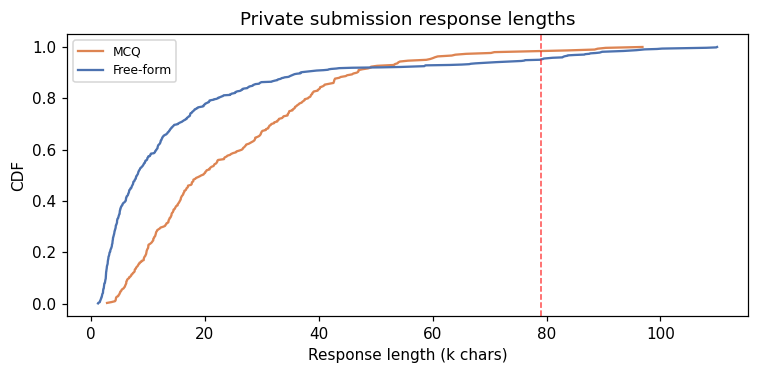

In [8]:
def _len_stats(sub: pd.DataFrame, name: str) -> None:
    if sub.empty:
        return
    s = sub.resp_len
    print(
        f"  {name:<12} mean={s.mean():,.0f}  median={s.median():,.0f}  "
        f"p95={s.quantile(0.95):,.0f}  max={s.max():,.0f}"
    )


print("Response length (chars)")
_len_stats(df, "Overall")
_len_stats(mcq, "MCQ")
_len_stats(ff, "Free-form")

if HAS_MPL and len(df):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    for label, sub, color in [("MCQ", mcq, "#DD8452"), ("Free-form", ff, "#4C72B0")]:
        if sub.empty:
            continue
        s = np.sort(sub.resp_len / 1000)
        ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, color=color)
    ax.axvline(NEAR_CAP_CHARS / 1000, color="red", ls="--", lw=1, alpha=0.7)
    ax.set_xlabel("Response length (k chars)")
    ax.set_ylabel("CDF")
    ax.set_title("Private submission response lengths")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Optional paired comparison

In [9]:
if compare_by_id:
    diffs = []
    for r in rows:
        pid = r["id"]
        if pid not in compare_by_id:
            continue
        old = compare_by_id[pid]
        new = r["response"]
        old_fin = has_think_finished(old)
        new_fin = r["think_finished"]
        diffs.append(
            {
                "id": pid,
                "len_delta": len(new) - len(old),
                "trunc_flip": old_fin and not new_fin,
                "untrunc_flip": (not old_fin) and new_fin,
                "fmt_a": r["mcq_boxed"] if r["is_mcq"] else r["count_ok"],
            }
        )
    if diffs:
        ddf = pd.DataFrame(diffs)
        print(f"Paired ids: {len(ddf)}")
        print(f"  Mean len delta: {ddf.len_delta.mean():+.0f} chars")
        print(f"  Newly truncated: {ddf.trunc_flip.sum()}")
        print(f"  Recovered from trunc: {ddf.untrunc_flip.sum()}")
    else:
        print("No overlapping ids with compare file.")
else:
    print("Set COMPARE_PATH to diff two response files.")

Set COMPARE_PATH to diff two response files.


## 10. Trace browser

In [10]:
INSPECT_ID = TRUNCATED_IDS[0] if TRUNCATED_IDS else (MISFORMAT_IDS[0] if MISFORMAT_IDS else df.id.iloc[0])


def show_trace(qid: int) -> None:
    row = df[df.id == qid].iloc[0]
    print(f"id={qid}  mcq={row.is_mcq}  think_finished={row.think_finished}")
    print(f"n_blanks={row.n_blanks}  n_extracted={row.n_extracted}  preview={row.extracted_preview!r}")
    print(f"resp_len={row.resp_len}  topic={row.topic}")
    print("-" * 60)
    print(f"Q: {row.question[:400]}{'…' if len(row.question) > 400 else ''}")
    print("-" * 60)
    print(row.response)


show_trace(INSPECT_ID)

id=19  mcq=True  think_finished=False
n_blanks=1  n_extracted=0  preview='A'
resp_len=58885  topic=sequences/recurrences
------------------------------------------------------------
Q: Consider the sequence defined by $j_0=1$, $j_1=2$, and $j_c=4j_{c-1}-j_{c-2}$ for $c\geq 2$. Determine the smallest odd prime factor of $j_{155}$.
------------------------------------------------------------
Okay, let's try to tackle this problem step by step. The problem is about a sequence defined by \( j_0 = 1 \), \( j_1 = 2 \), and \( j_c = 4j_{c-1} - j_{c-2} \) for \( c \geq 2 \). We need to find the smallest odd prime factor of \( j_{155} \).

First, let's recall that for linear recurrence relations, especially second-order linear recursions with constant coefficients, we can find a closed-form formula using characteristic equations. The characteristic equation for this recurrence is \( r^2 - 4r + 1 = 0 \). Solving this, we get roots \( r = \frac{4 \pm \sqrt{16 - 4}}{2} = 2 \pm \sqrt{3} \). So the 

## 11. Leaderboard score vs pub-003 (32k public baseline)

Private has no labels — compare reported **leaderboard unified accuracy** to pub-003 on `public.jsonl`, then decompose the gap using **format-risk buckets** (truncated / misformat / clean) calibrated on public 32k outputs.

LEADERBOARD vs pub-003 (32k, public.jsonl n=1126)
  Private leaderboard (priv-001):  48.00%  (~453/943 est.)
  Public baseline  (pub-003): 65.81%
  Gap (private − public):          -17.8 pp

  Public 32k by split:
    MCQ      81.07%  (n=375)
    Free-form 58.19%  (n=751)
  Private split (same pipeline, no labels):
    MCQ      n=300  format_ok=97.7%
    Free-form n=643  count_ok=93.0%

Format-risk bucket accuracy (calibrated on public 32k):
  truncated    pub acc=18.2%  (n=11)
  misformat    pub acc=7.7%  (n=26)
  clean        pub acc=67.7%  (n=1089)
  clean MCQ    pub acc=82.3%
  clean FF     pub acc=60.2%

Bucket mix — public vs private:
  truncated     pub   1.0% (  11)  priv   3.1% (  29)  Δ +2.1 pp
  misformat     pub   2.3% (  26)  priv   4.9% (  46)  Δ +2.6 pp
  clean         pub  96.7% (1089)  priv  92.0% ( 868)  Δ -4.7 pp

Gap decomposition (private n=943):
  Expected acc (public bucket rates × private mix): 63.24%
  Observed leaderboard:                         48.00%
  Resi

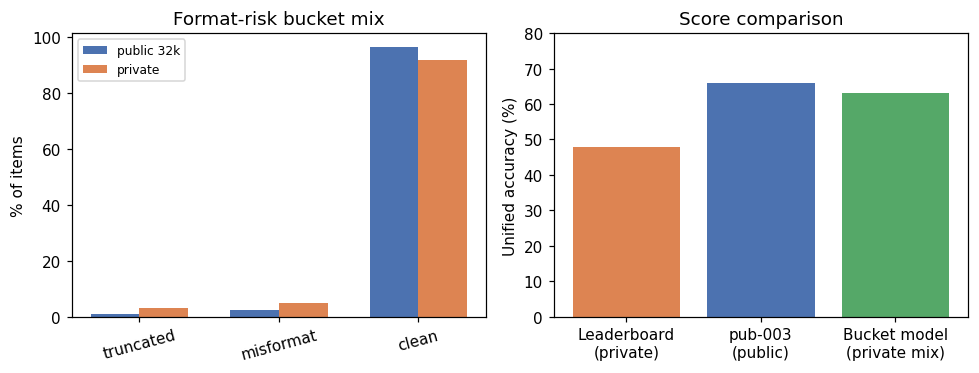

In [11]:
def _risk_bucket(row) -> str:
    if not row.think_finished:
        return "truncated"
    fmt_ok = row.mcq_boxed if row.is_mcq else row.count_ok
    return "clean" if fmt_ok else "misformat"


df["risk_bucket"] = df.apply(_risk_bucket, axis=1)

# pub-003 headline (full public 32k eval — docs/analysis/baseline-public-32k.md)
PUB_HEADLINE = {
    "overall": 741 / 1126,
    "mcq": 304 / 375,
    "ff": 437 / 751,
}

pub_items = {item["id"]: item for item in load_jsonl(PUBLIC_PATH)}
pub_scored = [json.loads(line) for line in PUBLIC_32K_PATH.open(encoding="utf-8") if line.strip()]

pub_rows = []
for rec in pub_scored:
    item = pub_items[rec["id"]]
    q = item.get("question", "")
    opts = item.get("options") or []
    is_mcq = bool(opts)
    resp = rec["response"]
    tail = response_tail(resp)
    n_blanks = 1 if is_mcq else n_ans_placeholders(q)
    boxed = extract_all_boxed(tail) if not is_mcq else []
    think_finished = has_think_finished(resp)
    count_ok = (not is_mcq) and (len(boxed) == n_blanks)
    mcq_boxed = mcq_has_boxed_letter(resp, len(opts)) if is_mcq else False
    fmt_ok = mcq_boxed if is_mcq else count_ok
    if not think_finished:
        bucket = "truncated"
    elif fmt_ok:
        bucket = "clean"
    else:
        bucket = "misformat"
    pub_rows.append(
        {
            "id": rec["id"],
            "is_mcq": is_mcq,
            "correct": rec["correct"],
            "think_finished": think_finished,
            "format_ok": fmt_ok,
            "risk_bucket": bucket,
            "topic": classify_topic(q),
            "n_blanks": n_blanks,
            "q_len": len(q),
        }
    )

pub_df = pd.DataFrame(pub_rows)

bucket_acc = (
    pub_df.groupby("risk_bucket", observed=True)["correct"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "acc", "count": "n"})
)
clean_mcq_acc = pub_df[(pub_df.risk_bucket == "clean") & pub_df.is_mcq]["correct"].mean()
clean_ff_acc = pub_df[(pub_df.risk_bucket == "clean") & ~pub_df.is_mcq]["correct"].mean()

priv_bucket = df.risk_bucket.value_counts().sort_index()
pub_bucket = pub_df.risk_bucket.value_counts().sort_index()

print("=" * 60)
print(f"LEADERBOARD vs {PUB_32K_RUN} (32k, public.jsonl n=1126)")
print("=" * 60)
print(f"  Private leaderboard ({RUN_ID}):  {LEADERBOARD_SCORE:.2%}  (~{LEADERBOARD_SCORE * len(df):.0f}/{len(df)} est.)")
print(f"  Public baseline  ({PUB_32K_RUN}): {PUB_HEADLINE['overall']:.2%}")
print(f"  Gap (private − public):          {100 * (LEADERBOARD_SCORE - PUB_HEADLINE['overall']):+.1f} pp")
print()
print("  Public 32k by split:")
print(f"    MCQ      {PUB_HEADLINE['mcq']:.2%}  (n=375)")
print(f"    Free-form {PUB_HEADLINE['ff']:.2%}  (n=751)")
print(f"  Private split (same pipeline, no labels):")
print(f"    MCQ      n={len(mcq)}  format_ok={mcq.mcq_boxed.mean():.1%}")
print(f"    Free-form n={len(ff)}  count_ok={ff.count_ok.mean():.1%}")
print()

print("Format-risk bucket accuracy (calibrated on public 32k):")
for bucket in ["truncated", "misformat", "clean"]:
    if bucket in bucket_acc.index:
        r = bucket_acc.loc[bucket]
        print(f"  {bucket:<12} pub acc={r.acc:.1%}  (n={int(r.n)})")
print(f"  clean MCQ    pub acc={clean_mcq_acc:.1%}")
print(f"  clean FF     pub acc={clean_ff_acc:.1%}")
print()

print("Bucket mix — public vs private:")
for bucket in ["truncated", "misformat", "clean"]:
    pn = int(pub_bucket.get(bucket, 0))
    pv = int(priv_bucket.get(bucket, 0))
    print(
        f"  {bucket:<12}  pub {100 * pn / len(pub_df):5.1f}% ({pn:4d})  "
        f"priv {100 * pv / len(df):5.1f}% ({pv:4d})  "
        f"Δ {100 * (pv / len(df) - pn / len(pub_df)):+.1f} pp"
    )

# Expected correct if private bucket mix + public bucket accuracies
clean_mcq_n = int(((df.risk_bucket == "clean") & df.is_mcq).sum())
clean_ff_n = int(((df.risk_bucket == "clean") & ~df.is_mcq).sum())
trunc_n = int((df.risk_bucket == "truncated").sum())
mis_n = int((df.risk_bucket == "misformat").sum())
trunc_acc = bucket_acc.loc["truncated"].acc if "truncated" in bucket_acc.index else 0.0
mis_acc = bucket_acc.loc["misformat"].acc if "misformat" in bucket_acc.index else 0.0
est_correct = (
    trunc_n * trunc_acc
    + mis_n * mis_acc
    + clean_mcq_n * clean_mcq_acc
    + clean_ff_n * clean_ff_acc
)
est_acc = est_correct / len(df)

print()
print("Gap decomposition (private n=943):")
print(f"  Expected acc (public bucket rates × private mix): {est_acc:.2%}")
print(f"  Observed leaderboard:                         {LEADERBOARD_SCORE:.2%}")
print(f"  Residual (obs − bucket model):                {100 * (LEADERBOARD_SCORE - est_acc):+.1f} pp  ← reasoning / private-harder / LB subset")
print(f"  Format-mix drag vs public (pub − bucket model): {100 * (PUB_HEADLINE['overall'] - est_acc):+.1f} pp")

# Naive split projection
naive_proj = (len(mcq) * PUB_HEADLINE["mcq"] + len(ff) * PUB_HEADLINE["ff"]) / len(df)
print(f"  Naive MCQ/FF projection (public rates):         {naive_proj:.2%}")
print(f"  Residual vs naive:                            {100 * (LEADERBOARD_SCORE - naive_proj):+.1f} pp")

print()
print("Weak-topic slices (private format vs public 32k acc):")
topic_pub = (
    pub_df.groupby("topic")["correct"].agg(["mean", "count"]).rename(columns={"mean": "pub_acc", "count": "pub_n"})
)
for topic in ["geometry", "probability/stats", "sequences/recurrences", "polynomials/algebra"]:
    sub = df[df.topic == topic]
    if sub.empty:
        continue
    pub_row = topic_pub.loc[topic] if topic in topic_pub.index else None
    pub_s = f"{pub_row.pub_acc:.1%} (n={int(pub_row.pub_n)})" if pub_row is not None else "n/a"
    print(
        f"  {topic:<22} priv format_ok={sub.format_ok.mean():.1%}  "
        f"trunc={ (~sub.think_finished).mean():.1%}  pub_acc={pub_s}"
    )

print()
print("Multi-blank & long-question exposure (private format_ok):")
for label, sub in [
    ("FF n_blanks=1", ff[ff.n_blanks == 1]),
    ("FF n_blanks≥6", ff[ff.n_blanks >= 6]),
    (f"Q4-long ≥{Q4_LONG_CHARS}c", df[df.q_len >= Q4_LONG_CHARS]),
]:
    if len(sub):
        print(f"  {label:<18} n={len(sub):>3}  format_ok={sub.format_ok.mean():.1%}  trunc={(~sub.think_finished).mean():.1%}")

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    labels = ["truncated", "misformat", "clean"]
    x = np.arange(len(labels))
    w = 0.35
    pub_pct = [100 * pub_bucket.get(b, 0) / len(pub_df) for b in labels]
    priv_pct = [100 * priv_bucket.get(b, 0) / len(df) for b in labels]
    axes[0].bar(x - w / 2, pub_pct, w, label="public 32k", color="#4C72B0")
    axes[0].bar(x + w / 2, priv_pct, w, label="private", color="#DD8452")
    axes[0].set_xticks(x, labels, rotation=15)
    axes[0].set_ylabel("% of items")
    axes[0].set_title("Format-risk bucket mix")
    axes[0].legend(fontsize=8)

    acc_labels = ["Leaderboard\n(private)", f"{PUB_32K_RUN}\n(public)", "Bucket model\n(private mix)"]
    acc_vals = [100 * LEADERBOARD_SCORE, 100 * PUB_HEADLINE["overall"], 100 * est_acc]
    colors = ["#DD8452", "#4C72B0", "#55A868"]
    axes[1].bar(acc_labels, acc_vals, color=colors)
    axes[1].set_ylabel("Unified accuracy (%)")
    axes[1].set_ylim(0, 80)
    axes[1].set_title("Score comparison")
    plt.tight_layout()
    plt.show()

LEADERBOARD_ANALYSIS = {
    "leaderboard_score": LEADERBOARD_SCORE,
    "pub_overall": PUB_HEADLINE["overall"],
    "gap_vs_public_pp": 100 * (LEADERBOARD_SCORE - PUB_HEADLINE["overall"]),
    "bucket_model_acc": est_acc,
    "residual_vs_bucket_model_pp": 100 * (LEADERBOARD_SCORE - est_acc),
    "naive_mcq_ff_proj": naive_proj,
    "private_trunc_pct": float((df.risk_bucket == "truncated").mean() * 100),
    "private_misformat_pct": float((df.risk_bucket == "misformat").mean() * 100),
}

## 12. Export flags & summary

In [12]:
def _flags_for_row(row) -> list[str]:
    flags = []
    if not row.think_finished:
        flags.append("truncated")
    if row.is_mcq:
        if not row.mcq_boxed:
            flags.append("mcq_no_boxed")
    elif not row.count_ok:
        flags.append("misformat")
        if row.no_boxed:
            flags.append("no_boxed")
        elif row.count_short:
            flags.append("count_short")
        elif row.count_long:
            flags.append("count_long")
    return flags


flag_rows = []
for _, row in df.iterrows():
    flags = _flags_for_row(row)
    if flags:
        flag_rows.append({"id": int(row.id), "flags": flags})

summary = {
    "run_id": RUN_ID,
    "max_tokens": MAX_TOKENS,
    "responses_path": str(RESPONSES_PATH),
    "n_questions": len(private),
    "n_responses": len(response_by_id),
    "integrity_pass": all_pass,
    "truncated_n": int((~df.think_finished).sum()),
    "truncated_pct": float((~df.think_finished).mean() * 100),
    "mcq_boxed_pct": float(mcq.mcq_boxed.mean() * 100) if len(mcq) else None,
    "ff_count_ok_pct": float(ff.count_ok.mean() * 100) if len(ff) else None,
    "misformat_n": int((~ff.count_ok).sum()) if len(ff) else 0,
    "mean_resp_len": float(df.resp_len.mean()),
    "flagged_n": len(flag_rows),
    **LEADERBOARD_ANALYSIS,
}

print("=" * 52)
print(f"SUBMISSION QA — {RUN_ID} @ {MAX_TOKENS//1024}k")
print("=" * 52)
print(f"  Integrity gates     : {'PASS' if all_pass else 'FAIL'}")
print(f"  Rows                : {len(response_by_id)}/{len(private)}")
print(f"  Truncated mid-think : {(~df.think_finished).sum()} ({summary['truncated_pct']:.1f}%)")
if len(mcq):
    print(f"  MCQ boxed emission  : {summary['mcq_boxed_pct']:.1f}%")
if len(ff):
    print(f"  FF count_ok         : {summary['ff_count_ok_pct']:.1f}%")
    print(f"  FF misformat        : {summary['misformat_n']}")
print(f"  Mean response len   : {summary['mean_resp_len']:,.0f} chars")
print(f"  Flagged ids         : {len(flag_rows)}")
if LEADERBOARD_SCORE is not None:
    print(f"  Leaderboard score   : {LEADERBOARD_SCORE:.2%}")
    print(f"  Gap vs pub-003      : {summary['gap_vs_public_pp']:+.1f} pp")
print("=" * 52)

FLAGS_PATH.parent.mkdir(parents=True, exist_ok=True)
with FLAGS_PATH.open("w", encoding="utf-8") as f:
    for rec in flag_rows:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")
with SUMMARY_PATH.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Wrote {len(flag_rows)} flagged rows → {FLAGS_PATH}")
print(f"Wrote summary → {SUMMARY_PATH}")
if flag_rows:
    print(f"Regen candidates (first 30): {[r['id'] for r in flag_rows[:30]]}")

SUBMISSION QA — priv-001 @ 32k
  Integrity gates     : PASS
  Rows                : 943/943
  Truncated mid-think : 29 (3.1%)
  MCQ boxed emission  : 97.7%
  FF count_ok         : 93.0%
  FF misformat        : 45
  Mean response len   : 19,050 chars
  Flagged ids         : 75
  Leaderboard score   : 48.00%
  Gap vs pub-003      : -17.8 pp
Wrote 75 flagged rows → /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/results/submission_flags.jsonl
Wrote summary → /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/results/submission_analysis_summary.json
Regen candidates (first 30): [7, 16, 19, 27, 41, 54, 58, 83, 93, 95, 105, 112, 120, 161, 163, 198, 199, 204, 229, 247, 248, 250, 275, 285, 296, 308, 312, 316, 376, 378]
